#### HW03 — XOR, Fully-connected ANN, and Nonlinear Boundaries

### How it works

Reworked my layout a little bit but not 100% sure insofar all this I think.

HYPERBOLIC TANGENT APPARENLTY WORKS BETTER

The network is defined by a list like `[2, 2, 1]`:
- 2 inputs, 2 hidden neurons, 1 output
- Between each pair of adjacent layers we store a **weight matrix**
- Each weight matrix gets **+1 row for bias** (we concatenate a 1 to each layer's activation)

Forward pass: loop through layers, multiply by weights, activate.
Backward pass: loop in reverse, compute deltas, update weights.

This generalizes to any architecture — `[2, 2, 1]`, `[2, 2, 2, 1]`, etc.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_prime(a):
    return a * (1.0 - a)

def tanh(x):
    return 2.0 / (1.0 + np.exp(-2 * x)) - 1.0

def tanh_prime(a):
    return 1.0 - a ** 2

In [4]:
class NeuralNetwork:

    def __init__(self, layers, activation='sigmoid'):
        self.layers = layers
        self.weights = [np.random.randn(m + 1, n) * 0.5
                        for m, n in zip(layers[:-1], layers[1:])]
        funcs = {'sigmoid': (sigmoid, sigmoid_prime), 'tanh': (tanh, tanh_prime)}
        self.act, self.act_prime = funcs[activation]

    def _forward(self, X):
        '''Full forward pass — returns (activations, biased_activations).'''
        acts, biased = [X], []
        a = X
        for w in self.weights:
            ab = np.c_[a, np.ones(len(a))]
            biased.append(ab)
            a = self.act(ab @ w)
            acts.append(a)
        return acts, biased

    def predict(self, x):
        return self._forward(x)[0][-1]

    def find_RMS_error(self, X, y):
        return float(np.sqrt(np.mean((self.predict(X) - y.reshape(-1, 1)) ** 2)))

    def fit(self, X, y, learning_rate=0.2, steps=100000, tol=1e-2):
        y = y.reshape(-1, 1)
        self.rms_history = []
        report_every = steps // 10

        for step in range(steps):
            acts, biased = self._forward(X)
            output = acts[-1]

            # backprop
            delta = (y - output) * self.act_prime(output)
            for i in reversed(range(len(self.weights))):
                grad = biased[i].T @ delta
                if i > 0:
                    delta = (delta @ self.weights[i].T)[:, :-1] * self.act_prime(acts[i])
                self.weights[i] += learning_rate * grad

            rms_err = self.find_RMS_error(X, y)
            self.rms_history.append(rms_err)

            if step % report_every == 0:
                print(f"step: {step}")
                print("Training Results(data, prediction, expected):")
                for xj, oj, yj in zip(X, output, y):
                    print(f"[{int(xj[0])} {int(xj[1])}], {oj[0]:.5f}, {int(yj[0])}")
                print(f"RMS_err: {rms_err:.5f}\n")

            if rms_err < tol:
                print("NN training succeeded!")
                break
        else:
            print("NN training failed.")

    def visual_NN_boundaries(self, Nsamp=2000):
        n = int(np.sqrt(Nsamp))
        xs = np.linspace(0, 1, n)
        X0, X1 = np.meshgrid(xs, xs)
        preds = self.predict(np.c_[X0.ravel(), X1.ravel()]).reshape(X0.shape)

        plt.figure(figsize=(6, 5))
        mesh = plt.pcolormesh(X0, X1, preds, cmap='coolwarm', shading='auto')
        plt.contour(X0, X1, preds, levels=[0.5], colors='black', linewidths=1.5)
        plt.colorbar(mesh, label='predicted class')
        plt.xlabel('x[0]')
        plt.ylabel('x[1]')
        plt.title('Decision Boundary')
        plt.show()

In [5]:
ACTIVATION = 'sigmoid'  

nn = NeuralNetwork([2, 2, 1], activation=ACTIVATION)

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([0, 1, 1, 0])

nn.fit(X, y, learning_rate=0.5, steps=100000)

step: 0
Training Results(data, prediction, expected):
[0 0], 0.52593, 0
[0 1], 0.52179, 1
[1 0], 0.54672, 1
[1 1], 0.54197, 0
RMS_err: 0.50063

step: 10000
Training Results(data, prediction, expected):
[0 0], 0.01901, 0
[0 1], 0.98359, 1
[1 0], 0.98359, 1
[1 1], 0.01697, 0
RMS_err: 0.01723

step: 20000
Training Results(data, prediction, expected):
[0 0], 0.01298, 0
[0 1], 0.98891, 1
[1 0], 0.98891, 1
[1 1], 0.01140, 0
RMS_err: 0.01167

NN training succeeded!


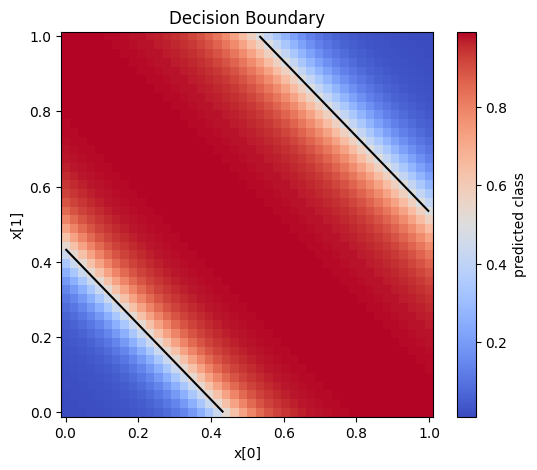

In [6]:
nn.visual_NN_boundaries(Nsamp=2000)

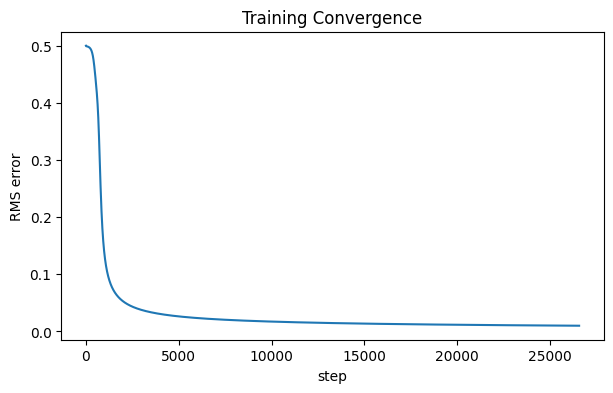

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(nn.rms_history)
plt.xlabel('step')
plt.ylabel('RMS error')
plt.title('Training Convergence')
plt.show()

# Part II — Nonlinear boundary with a deeper network

Same class, just pass `[2, 2, 2, 1]` instead of `[2, 2, 1]`.
The loop-based design handles the extra layer automatically.

In [ ]:
ACTIVATION = 'tanh'  

nn2 = NeuralNetwork([2, 2, 2, 1], activation=ACTIVATION)

X2 = np.array([[0, 0],
               [0, 1],
               [0.5, 1],
               [0, 0.5],
               [1, 0],
               [1, 1]])

y2 = np.array([0, 0, 0, 1, 1, 1])

nn2.fit(X2, y2, learning_rate=0.001, steps=1000000)

step: 0
Training Results(data, prediction, expected):
[0 0], -0.28626, 0
[0 1], -0.22821, 0
[0 1], -0.20870, 0
[0 0], -0.25432, 1
[1 0], -0.23846, 1
[1 1], -0.18928, 1
RMS_err: 0.88023

step: 100000
Training Results(data, prediction, expected):
[0 0], 0.34106, 0
[0 1], 0.32243, 0
[0 1], 0.00209, 0
[0 0], 0.33401, 1
[1 0], 0.97577, 1
[1 1], 0.96696, 1
RMS_err: 0.33304

step: 200000
Training Results(data, prediction, expected):
[0 0], 0.06636, 0
[0 1], 0.24199, 0
[0 1], -0.13368, 0
[0 0], 0.68475, 1
[1 0], 0.96613, 1
[1 1], 0.90439, 1
RMS_err: 0.17818



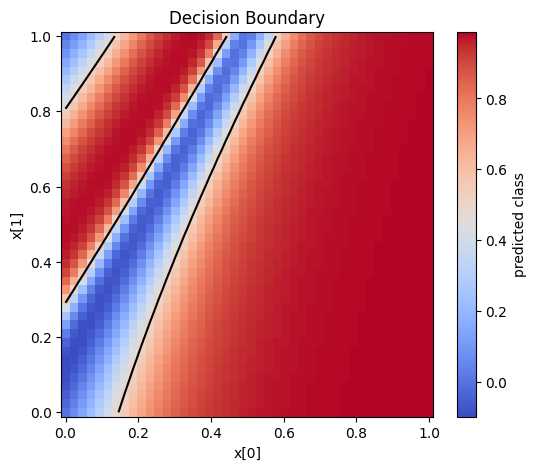

In [ ]:
nn2.visual_NN_boundaries(Nsamp=2000)